# Lab: Subset Selection Methods
## CMSE 381 - Spring 2022
## Feb 25, 2022



##ANSWER## 

Instructor notes:

Made use of this python translation of the lab: https://www.science.smith.edu/~jcrouser/SDS293/labs/lab8-py.html

Note: needed to update the `Hitters.csv` file I found online to have the label `Player` in the first column


## Notes from class Feb 2022

I was on the michigan flyer so couldn't actually be there. Emily Bolger (my TA) ran it. 

*Notes from her:*

Okay it was a little crazy, but it went well! Most students didn’t get to the backward selection part. And I have two notes for sources of confusion:
- People took the y dataframe wording literally and made the salary column a fulll dataframe, which obviously doesn’t work with the proccessSubset function
- People didn’t drop ‘Salary’ from their dataset, so they wondered why they were getting 0 for their RSS values.
- Most students got itertools happy and wanted to use it for the forward selection

In this module we are going to test out the subset selections methods we discussed in class from Chapter 6.1.

In [22]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sm
import time

# Loading in the data

Ok, here we go, let's play with a baseball data set. 

In [2]:
hitters_df = pd.read_csv('Hitters.csv')
hitters_df.head()

,Player,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


Annoyingly enough we have some missing values in the data.

In [3]:
print("Number of null values:", hitters_df["Salary"].isnull().sum())


Number of null values: 59


So let's go clean those up

In [4]:
# Print the dimensions of the original Hitters data (322 rows x 20 columns)
print("Dimensions of original data:", hitters_df.shape)

# Drop any rows the contain missing values, along with the player names
hitters_df = hitters_df.dropna().drop('Player', axis=1)

# Print the dimensions of the modified Hitters data (263 rows x 20 columns)
print("Dimensions of modified data:", hitters_df.shape)

# One last check: should return 0
print("Number of null values:", hitters_df["Salary"].isnull().sum())

Dimensions of original data: (322, 21)
Dimensions of modified data: (263, 20)
Number of null values: 0


# Best subset selection

Whew, ok, the data clean up is out of the way (you're welcome) so lets get to the fun part. First, let's play around with the `itertools` package which lets us automatically get subsets of things using the `combinations` function. 

In [5]:
import itertools 

In [6]:
my_set = ['apples','oranges','bananas','pomegranates','grapes']
for combo in itertools.combinations(my_set,3):
    print(combo)

('apples', 'oranges', 'bananas')
('apples', 'oranges', 'pomegranates')
('apples', 'oranges', 'grapes')
('apples', 'bananas', 'pomegranates')
('apples', 'bananas', 'grapes')
('apples', 'pomegranates', 'grapes')
('oranges', 'bananas', 'pomegranates')
('oranges', 'bananas', 'grapes')
('oranges', 'pomegranates', 'grapes')
('bananas', 'pomegranates', 'grapes')


Note that the code above produces an `iterator`, which means I really need to have it used inside of a for loop. If I just try to print it out, I get this:

In [7]:
print(itertools.combinations(my_set,3))

&#9989; **<font color=red>Do this:</font>** Write a script that prints all subsets of `my_set` of size 1 through 4. 


In [8]:
# Your code here #


In [9]:
##ANSWER##
my_set = ['apples','oranges','bananas','pomegranates','grapes']
for i in range(1,5): # <------ just need to wrap with a loop
    for combo in itertools.combinations(my_set,i):
        print(combo)

('apples',)
('oranges',)
('bananas',)
('pomegranates',)
('grapes',)
('apples', 'oranges')
('apples', 'bananas')
('apples', 'pomegranates')
('apples', 'grapes')
('oranges', 'bananas')
('oranges', 'pomegranates')
('oranges', 'grapes')
('bananas', 'pomegranates')
('bananas', 'grapes')
('pomegranates', 'grapes')
('apples', 'oranges', 'bananas')
('apples', 'oranges', 'pomegranates')
('apples', 'oranges', 'grapes')
('apples', 'bananas', 'pomegranates')
('apples', 'bananas', 'grapes')
('apples', 'pomegranates', 'grapes')
('oranges', 'bananas', 'pomegranates')
('oranges', 'bananas', 'grapes')
('oranges', 'pomegranates', 'grapes')
('bananas', 'pomegranates', 'grapes')
('apples', 'oranges', 'bananas', 'pomegranates')
('apples', 'oranges', 'bananas', 'grapes')
('apples', 'oranges', 'pomegranates', 'grapes')
('apples', 'bananas', 'pomegranates', 'grapes')
('oranges', 'bananas', 'pomegranates', 'grapes')


## Back to the data
Ok, back to the data set.  We're going work with linear regression models using the available inputs to predict the player salaries. Our goal is to check all the subsets (up to a limit cuz the computation time is narsty) and find the best one, where `best` is defined as the lowest RSS

We're first going to set this bit up so that we have dummy variables for the three categorical variables. Turns out pandas can do all my work for me.

In [10]:
dummies = pd.get_dummies(hitters_df[['League', 'Division', 'NewLeague']])
dummies

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,0,1,0,1,0,1
2,1,0,0,1,1,0
3,0,1,1,0,0,1
4,0,1,1,0,0,1
5,1,0,0,1,1,0
...,...,...,...,...,...,...
317,0,1,1,0,0,1
318,1,0,1,0,1,0
319,1,0,0,1,1,0
320,1,0,1,0,1,0


&#9989; **<font color=red>Q:</font>** 
- What do the column names in the `dummies` data frame mean?  
- What does a row with all 0 entries mean about the original data point?


In [11]:
# Your code here, you might need to test some things out to figure out the answers above #


In [12]:
##ANSWER##

# The value after the subscript is the value of the set it represents
print('Elements of League:', set(hitters_df['League']))
print('Elements of Division:', set(hitters_df['Division']))
print('Elements of NewLeague:', set(hitters_df['NewLeague']))

# This is a trick question, there's no way in this setting to actually get an all 0 vector since 
# the dummy variable setup doesn't have a baseline in this case.

Elements of League: {'A', 'N'}
Elements of Division: {'E', 'W'}
Elements of NewLeague: {'A', 'N'}


&#9989; **<font color=red>Do this:</font>** 
- Make a new data frame `y` with just the `Salary` data. 
- Make a new data frame `X` by dropping the original categorical variables from `hitters_df` and putting in the dummy variables for `League_N`, `Division_W`, and `NewLeague_N`.
    - Important: Why am I not using ALL the variables from the `dummies` data frame?


In [13]:
# Your code here#


In [14]:
##ANSWER##

y = hitters_df.Salary

# Drop the column with the independent variable (Salary), and columns for which we created dummy variables
X_ = hitters_df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')

# Define the feature set X.
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis=1)

# Note that only adding one from each two level dummy variable means the other variable is the baseline.  
# So now it makes sense to have a data point with a 0 entry for all three.

The function `processSubset` takes in a list of features, then trains the model using the portion of the `X` data frame. 

In [17]:
def processSubset(feature_set):
    # Fit model on feature_set and calculate RSS
    model = sm.OLS(y,X[list(feature_set)])
    regr = model.fit()
    RSS = ((regr.predict(X[list(feature_set)]) - y) ** 2).sum()
    return {"model":regr, "RSS":RSS}

&#9989; **<font color=red>Do this:</font>** Use the `processSubset` function to get the model and RSS for the model where we predict salary using `RBI`, `CWalks`, and `League_N`. 


In [18]:
# Your code here #

In [47]:
##ANSWER##
processSubset(['RBI','CWalks','League_N'])

{'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7ff8fbbd3af0>,
 'RSS': 33974578.41301793}

This next function, `getBest` should take an integer `k` and create a data frame with all the resulting models and RSS values for each possible subset of size `k`. In the notation from the last class, this functing is finding $\mathcal{M}_k$.

&#9989; **<font color=red>Do this:</font>** Fix the code below to actually work. Which two variables are used by the best model $\mathcal{M}_2$?


In [37]:
#---- you modify this function to actually work -----#
def getBest(k):
    
    # This function just keeps track of time for me 
    tic = time.time()
    
    results = []
    
    #---------Your code here--------#
    # use the itertools stuff from above to get all subsets
    # append the results of processSubset for each set 
    # to the list results
    #
    # Delete the line below here, it's just a placeholder so that the code 
    # runs before you add your code 
    results.append({'model':None,"RSS":42}) # DELETE ME!!! #
    #-------------------------------#
    
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS 
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed", models.shape[0], "models on", k, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model


# Tester down here
getBest(2)

Processed 1 models on 2 predictors in 0.002972841262817383 seconds.


model    None
RSS        42
Name: 0, dtype: object

In [44]:
##ANSWER##

def getBest(k):
    
    tic = time.time()
    
    results = []
    
    for combo in itertools.combinations(X.columns, k):
        results.append(processSubset(combo))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed", models.shape[0], "models on", k, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

print(getBest(2)['model'].summary()) #<------ The summary function has the variables 
                                     # listed as rows in one of the output matrices. 
                                     # I got Hits and CRBI.

Processed 171 models on 2 predictors in 0.3995170593261719 seconds.
                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.761
Model:                            OLS   Adj. R-squared (uncentered):              0.760
Method:                 Least Squares   F-statistic:                              416.7
Date:                Thu, 24 Feb 2022   Prob (F-statistic):                    5.80e-82
Time:                        15:14:02   Log-Likelihood:                         -1907.6
No. Observations:                 263   AIC:                                      3819.
Df Residuals:                     261   BIC:                                      3826.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|

Now that you've got that working, let's find $\mathcal{M_k}$ for all $k$ up through subsets of size 7. 

**<font color=red>WARNING:</font>** This code might take a while, my computer took about 3 minutes to get through 7.  You can modify the code if you want to get up through 8, which took my computer a total of 6 minutes to get through but your results may vary. Now's a great time to hit enter and then take a stretch break.

In [64]:
# Could take quite a while to complete... 

models_best = pd.DataFrame(columns=["RSS", "model"])

tic = time.time()
for i in range(1,8):
    models_best.loc[i] = getBest(i)

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")

Processed 19 models on 1 predictors in 0.07034730911254883 seconds.
Processed 171 models on 2 predictors in 0.31303906440734863 seconds.
Processed 969 models on 3 predictors in 1.6962006092071533 seconds.
Processed 3876 models on 4 predictors in 7.563657999038696 seconds.
Processed 11628 models on 5 predictors in 23.58157992362976 seconds.
Processed 27132 models on 6 predictors in 56.211188077926636 seconds.
Processed 50388 models on 7 predictors in 107.96895503997803 seconds.
Processed 75582 models on 8 predictors in 157.52144479751587 seconds.
Total elapsed time: 355.6922719478607 seconds.


In [46]:
models_best

,RSS,model
1,4.321393e+07,<statsmodels.regression.linear_model.Regressio...
2,3.073305e+07,<statsmodels.regression.linear_model.Regressio...
3,2.941071e+07,<statsmodels.regression.linear_model.Regressio...
4,2.797678e+07,<statsmodels.regression.linear_model.Regressio...
5,2.718780e+07,<statsmodels.regression.linear_model.Regressio...
6,2.639772e+07,<statsmodels.regression.linear_model.Regressio...
7,2.606413e+07,<statsmodels.regression.linear_model.Regressio...


Notice that the `model` column actually is storing the model determined by stats model, so you can get it out to get info.

&#9989; **<font color=red>Do this:</font>** Without rerunning anything, what are the three variables used in $\mathcal{M}_3$? What is the $R^2$ value of the resulting model? What is the AIC of the resulting model?


In [ ]:
# Your code here #

In [67]:
##ANSWER##
print('Rsquared:', models_best.loc[3, "model"].rsquared)
print('AIC:', models_best.loc[3, "model"].aic)

models_best.loc[3, "model"].summary()

# I see [Hits, CRBI, and Division_W] for the variables.

Rsquared: 0.7717570782136107
AIC: 3809.6618522039994


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Salary   R-squared (uncentered):                   0.772
Model:                            OLS   Adj. R-squared (uncentered):              0.769
Method:                 Least Squares   F-statistic:                              293.0
Date:                Thu, 24 Feb 2022   Prob (F-statistic):                    4.43e-83
Time:                        15:46:46   Log-Likelihood:                         -1901.8
No. Observations:                 263   AIC:                                      3810.
Df Residuals:                     260   BIC:                                      3820.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Hits           3.4057      0.288     11.842      0.000       2.839       3.972
CRBI           0.6964      0.065     10.742      0.000       0.569       0.824
Division_W  -129.1604     37.777     -3.419      0.001    -203.548     -54.773
==============================================================================
Omnibus:                      110.025   Durbin-Watson:                   1.893
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              621.594
Skew:                           1.589   Prob(JB):                    1.05e-135
Kurtosis:                       9.828   Cond. No.                         856.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The following script spits out the rsquared value for each model and returns it as a pandas series.

In [68]:
# Gets the second element from each row ('model') and pulls out its rsquared attribute
models_best.apply(lambda row: row[1].rsquared, axis=1)

1    0.664637
2    0.761495
3    0.771757
4    0.782885
5    0.789008
6    0.795140
7    0.797728
8    0.802259
dtype: float64

...and the next bit does this for all the test score approximations we talked about in class.....

Text(0, 0.5, 'BIC')

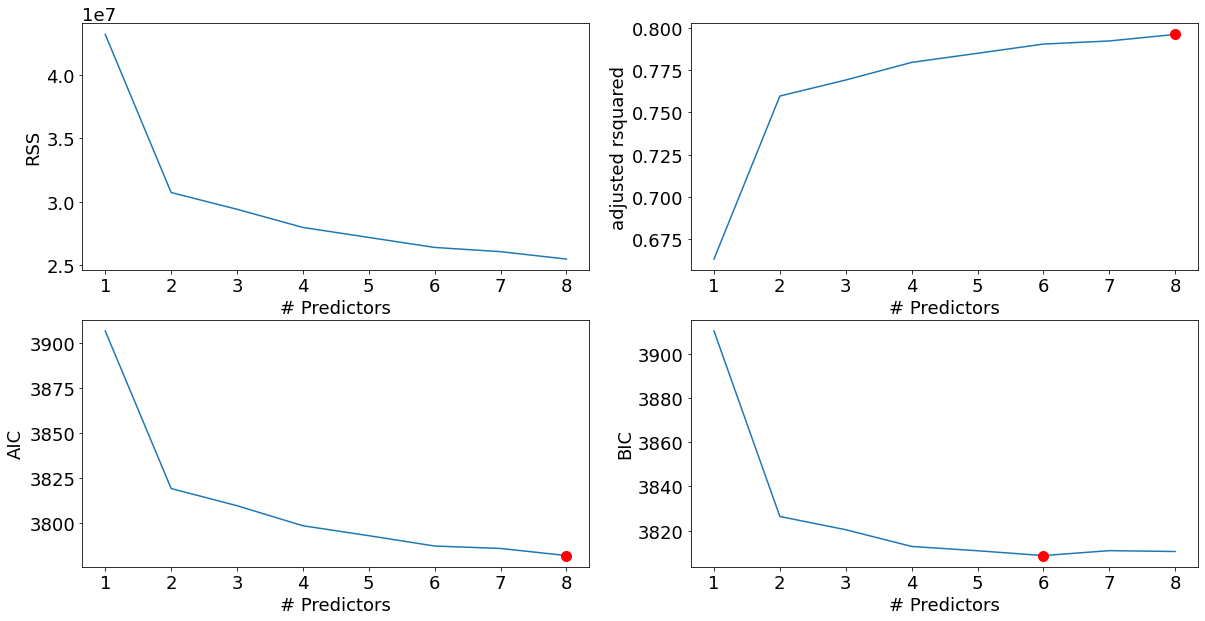

In [69]:
plt.figure(figsize=(20,10))
plt.rcParams.update({'font.size': 18, 'lines.markersize': 10})

# Set up a 2x2 grid so we can look at 4 plots at once
plt.subplot(2, 2, 1)

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector
plt.plot(models_best["RSS"])
plt.xlabel('# Predictors')
plt.ylabel('RSS')

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector

rsquared_adj = models_best.apply(lambda row: row[1].rsquared_adj, axis=1)

plt.subplot(2, 2, 2)
plt.plot(rsquared_adj)
plt.plot(rsquared_adj.argmax()+1, rsquared_adj.max(), "or")
plt.xlabel('# Predictors')
plt.ylabel('adjusted rsquared')

# We'll do the same for AIC and BIC, this time looking for the models with the SMALLEST statistic
aic = models_best.apply(lambda row: row[1].aic, axis=1)

plt.subplot(2, 2, 3)
plt.plot(aic)
plt.plot(aic.argmin()+1, aic.min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('AIC')

bic = models_best.apply(lambda row: row[1].bic, axis=1)

plt.subplot(2, 2, 4)
plt.plot(bic)
plt.plot(bic.argmin()+1, bic.min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('BIC')

# Forward selection

Ok, if nothing else, that amount of time that code takes to run is pretty frustrating.  We're going to implement forward selection as shown in Algorithm 6.2 in the book. First, let's figure out how to go through the for loop. Back to the fruits!

In [71]:
my_set

['apples', 'oranges', 'bananas', 'pomegranates', 'grapes']

Let's say that at step 2, I found out that the best model was the one that included `apples` and `bananas`. 

In [75]:
M2 = ['apples','bananas']
remaining_predictors = [p for p in my_set if p not in M2]

print(M2)
print(remaining_predictors)

['apples', 'bananas']
['oranges', 'pomegranates', 'grapes']


&#9989; **<font color=red>Do this:</font>** Print out all the size 3 sets of fruit-variables that will be checked at the next step in the forward algorithm. 


In [18]:
# Your code here #

In [80]:
##ANSWER##

for p in remaining_predictors:
    print(M2 + [p]) # <----- Note if they append, this will get bigger each time

['apples', 'bananas', 'oranges', 'pomegranates', 'grapes', 'oranges']
['apples', 'bananas', 'oranges', 'pomegranates', 'grapes', 'pomegranates']
['apples', 'bananas', 'oranges', 'pomegranates', 'grapes', 'grapes']


&#9989; **<font color=red>Do this:</font>** Modify this next function using what you figured out with the fruits. The input `predictors` is the list of variables `M_i`  from the hitters data set that were found to give the best model in the previous step.  


In [82]:
def forward(predictors):

    # Pull out predictors we still need to process
    remaining_predictors = [p for p in X.columns if p not in predictors]
    
    tic = time.time()
    
    results = []
    
    #----------your code here----------#
    # For each of the new variable sets, use processSubset
    # to do the model, and add the output to the results 
    # data frame.
    #
    # Delete the line below here, it's just a placeholder so that the code 
    # runs before you add your new code 
    results.append({'model':None,"RSS":42}) # DELETE ME!!! #
    #-------------------------------#
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)+1, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

forward(['Hits','CRBI'])

Processed  1 models on 3 predictors in 0.002515554428100586 seconds.


model    None
RSS        42
Name: 0, dtype: object

In [91]:
##ANSWER##
def forward(predictors):

    # Pull out predictors we still need to process
    remaining_predictors = [p for p in X.columns if p not in predictors]
    
    tic = time.time()
    
    results = []
    
    for p in remaining_predictors:
        results.append(processSubset(predictors+[p]))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)+1, "predictors in", round((toc-tic),4), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

forward(['Hits','CRBI'])

Processed  17 models on 3 predictors in 0.095 seconds.


model    <statsmodels.regression.linear_model.Regressio...
RSS                                        29410713.176731
Name: 15, dtype: object

And now we can wrap this party up in a huge for loop determine each $\mathcal{M}_i$

In [92]:
models_fwd = pd.DataFrame(columns=["RSS", "model"])

tic = time.time()

# We start with no variables at all in our model
predictors = []

for i in range(1,len(X.columns)+1): 
    
    # Now we run our forward one step function from above to get 
    # the best model.     
    models_fwd.loc[i] = forward(predictors)
    
    # Then we extract the names of the variables that were used 
    # in that found model. When the for loop repeats, this will 
    # get sent back to predictors to the next stup.
    predictors = models_fwd.loc[i]["model"].model.exog_names
    
    # If you want to get something printed out to see which 
    # variables are used at each step, uncomment this line:
#     print('Starting with predictors:\n', predictors)


toc = time.time()
print("Total elapsed time:", round((toc-tic),2), "seconds.")

Processed  19 models on 1 predictors in 0.1061 seconds.
Processed  18 models on 2 predictors in 0.0467 seconds.
Processed  17 models on 3 predictors in 0.0368 seconds.
Processed  16 models on 4 predictors in 0.0396 seconds.
Processed  15 models on 5 predictors in 0.0368 seconds.
Processed  14 models on 6 predictors in 0.0281 seconds.
Processed  13 models on 7 predictors in 0.0356 seconds.
Processed  12 models on 8 predictors in 0.0315 seconds.
Processed  11 models on 9 predictors in 0.0286 seconds.
Processed  10 models on 10 predictors in 0.0215 seconds.
Processed  9 models on 11 predictors in 0.0197 seconds.
Processed  8 models on 12 predictors in 0.0218 seconds.
Processed  7 models on 13 predictors in 0.0195 seconds.
Processed  6 models on 14 predictors in 0.0195 seconds.
Processed  5 models on 15 predictors in 0.0169 seconds.
Processed  4 models on 16 predictors in 0.0125 seconds.
Processed  3 models on 17 predictors in 0.0097 seconds.
Processed  2 models on 18 predictors in 0.007 s

Look at that, no streatch break needed! On my computer that took about a half second. 

We can use the following code to figure out which variables were used for each $M_i$

In [95]:
print(models_fwd.loc[1, "model"].model.exog_names)
print(models_fwd.loc[2, "model"].model.exog_names)

['Hits']
['Hits', 'CRBI']


&#9989; **<font color=red>Q:</font>** Did the forward stepwise selection find the same model of size 6 as the earlier version that checked all subsets of size 6? How does the $R^2$ value compare between the two? (Note.... you hopefully haven't overwritten `models_best` so you shouldn't have to rerun any long for loops)


In [ ]:
# Your code here 

In [100]:
##ANSWER##
# Not the same model, but basically the same score.

print('Best:', models_best.loc[6, "model"].model.exog_names)
print('R^2:', models_best.loc[6, "model"].rsquared, '\n')

print('Fwd:', models_fwd.loc[6, "model"].model.exog_names)
print('R^2:', models_fwd.loc[6, "model"].rsquared, '\n')


Best: ['AtBat', 'Hits', 'Walks', 'CRBI', 'PutOuts', 'Division_W']
R^2: 0.7951395186464754 

Fwd: ['Hits', 'CRBI', 'Division_W', 'PutOuts', 'AtBat', 'Walks']
R^2: 0.7951395186464754 



&#9989; **<font color=red>Q:</font>** Copy the figure plotting code from the best subsets model and modify it to see the various scores for your forward selection results. How does the size of the model chosen using each method ($R^2$, AIC, BIC) compare to the all subsets version?


In [ ]:
# Your code here 

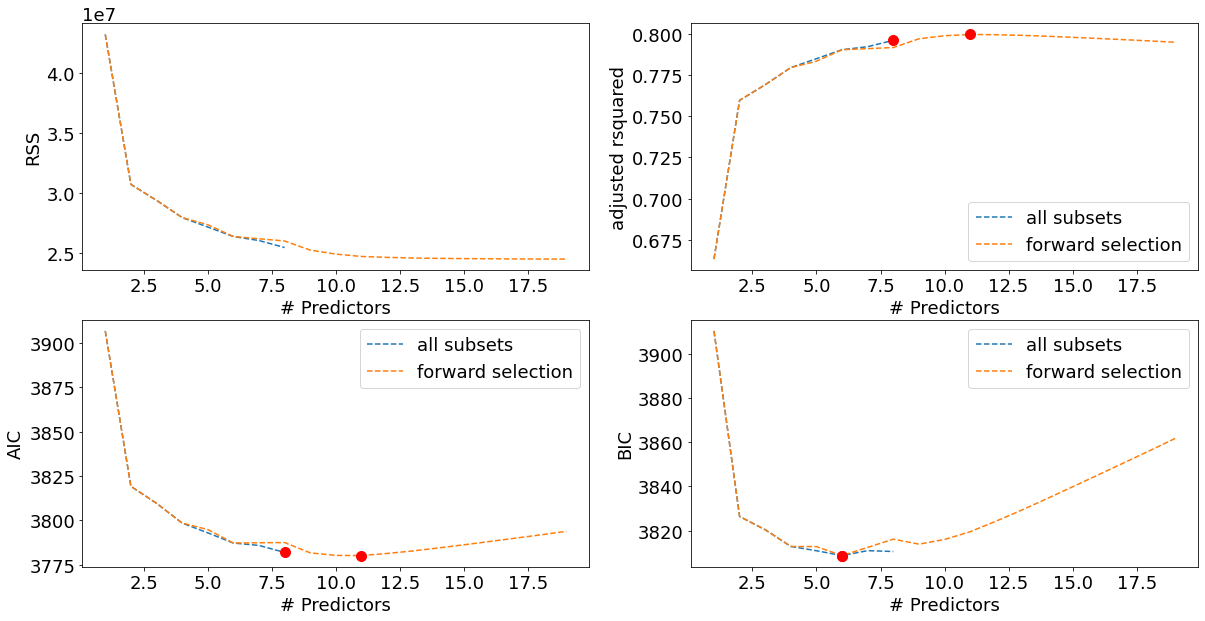

In [119]:
##ANSWER##

plt.figure(figsize=(20,10))
plt.rcParams.update({'font.size': 18, 'lines.markersize': 10})

# Set up a 2x2 grid so we can look at 4 plots at once
plt.subplot(2, 2, 1)

plt.plot(models_best["RSS"],'--')
plt.plot(models_fwd["RSS"],'--')

plt.xlabel('# Predictors')
plt.ylabel('RSS')

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector

#----R^2----------------------
plt.subplot(2, 2, 2)
# all subsets R^2
rsquared_adj = models_best.apply(lambda row: row[1].rsquared_adj, axis=1)
plt.plot(rsquared_adj,'--',label = 'all subsets',)
plt.plot(rsquared_adj.argmax()+1,rsquared_adj.max(), "or")

# forward R^2
rsquared_adj = models_fwd.apply(lambda row: row[1].rsquared_adj, axis=1)
plt.plot(rsquared_adj,'--', label = 'forward selection')
plt.plot(rsquared_adj.argmax()+1, rsquared_adj.max(), "or")

plt.legend()

plt.xlabel('# Predictors')
plt.ylabel('adjusted rsquared')



#----AIC----------------------

# We'll do the same for AIC and BIC, this time looking for the models with the SMALLEST statistic

plt.subplot(2, 2, 3)

# all subsets AIC
aic = models_best.apply(lambda row: row[1].aic, axis=1)
plt.plot(aic,'--',label = 'all subsets',)
plt.plot(aic.argmin()+1,aic.min(), "or")

# foward AIC
aic = models_fwd.apply(lambda row: row[1].aic, axis=1)
plt.plot(aic,'--', label = 'forward selection')
plt.plot(aic.argmin()+1, aic.min(), "or")

plt.xlabel('# Predictors')
plt.ylabel('AIC')

plt.legend()


#----BIC----------------------

plt.subplot(2, 2, 4)

# all subsets AIC
bic = models_best.apply(lambda row: row[1].bic, axis=1)
plt.plot(bic,'--',label = 'all subsets',)
plt.plot(bic.argmin()+1,bic.min(), "or")

# foward AIC
bic = models_fwd.apply(lambda row: row[1].bic, axis=1)
plt.plot(bic,'--', label = 'forward selection')
plt.plot(bic.argmin()+1, bic.min(), "or")


plt.xlabel('# Predictors')
plt.ylabel('BIC')
plt.legend()


# Backward Selection

Your final goal is to modify your forward function to get a new function `backward` which removes one variable at a time. 

&#9989; **<font color=red>Do this:</font>** Make the following function do what it should *a la* Algorithm 6.3.  That is, for a new list of predictors, write a for loop that removes one at a time, fits the model using `processSubset`, and adds the results to the data frame.

In [124]:
# You modify this code

def backward(predictors):
    
    tic = time.time()
    
    results = []
    
    #----------your code here----------#
    # For each of the new variable sets, use processSubset
    # to fit the model, and add the output to the results 
    # data frame.
    #
    # Delete the line below here, it's just a placeholder so that the code 
    # runs before you add your new code 
    results.append({'model':None,"RSS":42}) # DELETE ME!!! #
    #-------------------------------#
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)-1, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

backward(['Hits','CRBI','CWalks','Errors'])

Processed  1 models on 3 predictors in 0.0037567615509033203 seconds.


model    None
RSS        42
Name: 0, dtype: object

In [126]:
##ANSWER##
def backward(predictors):
    
    tic = time.time()
    
    results = []
    
    
    # Note that the students might not do it this way. They might go through the list of predictors one
    # at a time and remove from the set.  Either way should work.
    for combo in itertools.combinations(predictors, len(predictors)-1):
        results.append(processSubset(combo))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)-1, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

backward(['Hits','CRBI','CWalks','Errors'])

Processed  4 models on 3 predictors in 0.024959325790405273 seconds.


model    <statsmodels.regression.linear_model.Regressio...
RSS                                        30584459.473677
Name: 1, dtype: object

And again, we wrap this beast in a for loop and get a (potentially different) set of models $\mathcal{M}_k$ for each size $k$.

In [127]:
models_bwd = pd.DataFrame(columns=["RSS", "model"], index = range(1,len(X.columns)))

tic = time.time()
predictors = X.columns

while(len(predictors) > 1):  
    models_bwd.loc[len(predictors)-1] = backward(predictors)
    predictors = models_bwd.loc[len(predictors)-1]["model"].model.exog_names

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")

Processed  19 models on 18 predictors in 0.12863779067993164 seconds.
Processed  18 models on 17 predictors in 0.054608821868896484 seconds.
Processed  17 models on 16 predictors in 0.04713892936706543 seconds.
Processed  16 models on 15 predictors in 0.04443693161010742 seconds.
Processed  15 models on 14 predictors in 0.04016828536987305 seconds.
Processed  14 models on 13 predictors in 0.03984689712524414 seconds.
Processed  13 models on 12 predictors in 0.029500246047973633 seconds.
Processed  12 models on 11 predictors in 0.02511000633239746 seconds.
Processed  11 models on 10 predictors in 0.02251744270324707 seconds.
Processed  10 models on 9 predictors in 0.022555112838745117 seconds.
Processed  9 models on 8 predictors in 0.019707679748535156 seconds.
Processed  8 models on 7 predictors in 0.01603412628173828 seconds.
Processed  7 models on 6 predictors in 0.013413190841674805 seconds.
Processed  6 models on 5 predictors in 0.011607170104980469 seconds.
Processed  5 models on 

&#9989; **<font color=red>Do this:</font>** Are all three models of size 7 (the one from all subsets, the one from the forward selection, and the one from backward selection) the same? How do the $R^2$ values compare?


In [ ]:
# Your code here #

In [130]:
##ANSWER##

print("------------")
print("Best Subset:")
print("------------")
print(models_best.loc[7, "model"].params)
print(models_best.loc[7, "model"].rsquared)


print("-----------------")
print("Foward Selection:")
print("-----------------")
print(models_fwd.loc[7, "model"].params)
print(models_fwd.loc[7, "model"].rsquared)


print("-------------------")
print("Backward Selection:")
print("-------------------")
print(models_bwd.loc[7, "model"].params)
print(models_bwd.loc[7, "model"].rsquared)

------------
Best Subset:
------------
Hits            1.680029
Walks           3.399961
CAtBat         -0.328835
CHits           1.347017
CHmRun          1.349373
PutOuts         0.248166
Division_W   -111.943760
dtype: float64
0.797728355358859
-----------------
Foward Selection:
-----------------
Hits            7.277149
CRBI            0.652415
Division_W   -110.656338
PutOuts         0.259787
AtBat          -1.644651
Walks           3.684324
League_N       49.978410
dtype: float64
0.7965786456984845
-------------------
Backward Selection:
-------------------
AtBat         -1.601655
Hits           6.148449
Walks          5.866033
CRuns          1.097453
CWalks        -0.650614
PutOuts        0.310125
Division_W   -95.027171
dtype: float64
0.7967077043993955


&#9989; **<font color=red>Do this:</font>** Update the figure code above one more time to see which size set of variables is chosen by each test score method. If you have time, draw all three results on top of each other for easy visulalization.


In [131]:
# Your code here #

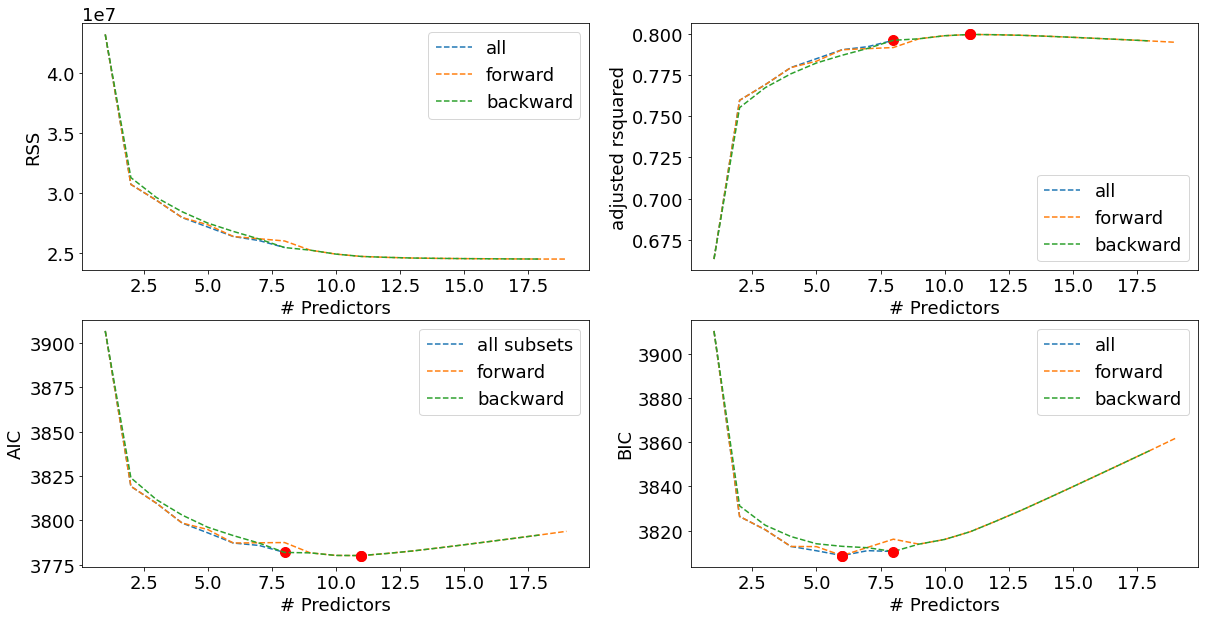

In [136]:
##ANSWER##

plt.figure(figsize=(20,10))
plt.rcParams.update({'font.size': 18, 'lines.markersize': 10})

# Set up a 2x2 grid so we can look at 4 plots at once
plt.subplot(2, 2, 1)

plt.plot(models_best["RSS"],'--',label = 'all')
plt.plot(models_fwd["RSS"],'--',label = 'forward')
plt.plot(models_bwd["RSS"],'--',label = 'backward')


plt.xlabel('# Predictors')
plt.ylabel('RSS')
plt.legend()

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector

#----R^2----------------------
plt.subplot(2, 2, 2)
# all subsets R^2
rsquared_adj = models_best.apply(lambda row: row[1].rsquared_adj, axis=1)
plt.plot(rsquared_adj,'--',label = 'all',)
plt.plot(rsquared_adj.argmax()+1,rsquared_adj.max(), "or")

# forward R^2
rsquared_adj = models_fwd.apply(lambda row: row[1].rsquared_adj, axis=1)
plt.plot(rsquared_adj,'--', label = 'forward')
plt.plot(rsquared_adj.argmax()+1, rsquared_adj.max(), "or")

# backward R^2
rsquared_adj = models_bwd.apply(lambda row: row[1].rsquared_adj, axis=1)
plt.plot(rsquared_adj,'--', label = 'backward')
plt.plot(rsquared_adj.argmax()+1, rsquared_adj.max(), "or")

plt.legend()

plt.xlabel('# Predictors')
plt.ylabel('adjusted rsquared')



#----AIC----------------------

# We'll do the same for AIC and BIC, this time looking for the models with the SMALLEST statistic

plt.subplot(2, 2, 3)

# all subsets AIC
aic = models_best.apply(lambda row: row[1].aic, axis=1)
plt.plot(aic,'--',label = 'all subsets',)
plt.plot(aic.argmin()+1,aic.min(), "or")

# foward AIC
aic = models_fwd.apply(lambda row: row[1].aic, axis=1)
plt.plot(aic,'--', label = 'forward')
plt.plot(aic.argmin()+1, aic.min(), "or")

# backward AIC
aic = models_bwd.apply(lambda row: row[1].aic, axis=1)
plt.plot(aic,'--', label = 'backward')
plt.plot(aic.argmin()+1, aic.min(), "or")

plt.xlabel('# Predictors')
plt.ylabel('AIC')

plt.legend()


#----BIC----------------------

plt.subplot(2, 2, 4)

# all subsets AIC
bic = models_best.apply(lambda row: row[1].bic, axis=1)
plt.plot(bic,'--',label = 'all',)
plt.plot(bic.argmin()+1,bic.min(), "or")

# foward AIC
bic = models_fwd.apply(lambda row: row[1].bic, axis=1)
plt.plot(bic,'--', label = 'forward')
plt.plot(bic.argmin()+1, bic.min(), "or")


# backward AIC
bic = models_bwd.apply(lambda row: row[1].bic, axis=1)
plt.plot(bic,'--', label = 'backward')
plt.plot(bic.argmin()+1, bic.min(), "or")


plt.xlabel('# Predictors')
plt.ylabel('BIC')
plt.legend()


# Lab Survey

To get credit for today's lab, fill out the following survey before the end of class:

https://forms.gle/hX8GT5FJ2fNMeTo1A

Note this is the same link for every lab, so you will fill this out multiple times this semester.



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [137]:
##ANSWER## 
# This cell gets the name of the current notebook. Needs a sec
# to run before it works

from jupyterinstruct import InstructorNotebook
this_notebook = InstructorNotebook.getname()


##ANSWER## 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [140]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

studentnotebook = InstructorNotebook.makestudent(this_notebook)
InstructorNotebook.validate(studentnotebook)

Myfilename Lab-SubsetSelection-INSTRUCTOR.ipynb


Lab-SubsetSelection.ipynb


Validating Notebook ./Lab-SubsetSelection.ipynb
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..


1